In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv("Iris.csv")

#EDA

In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.shape

(150, 6)

In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

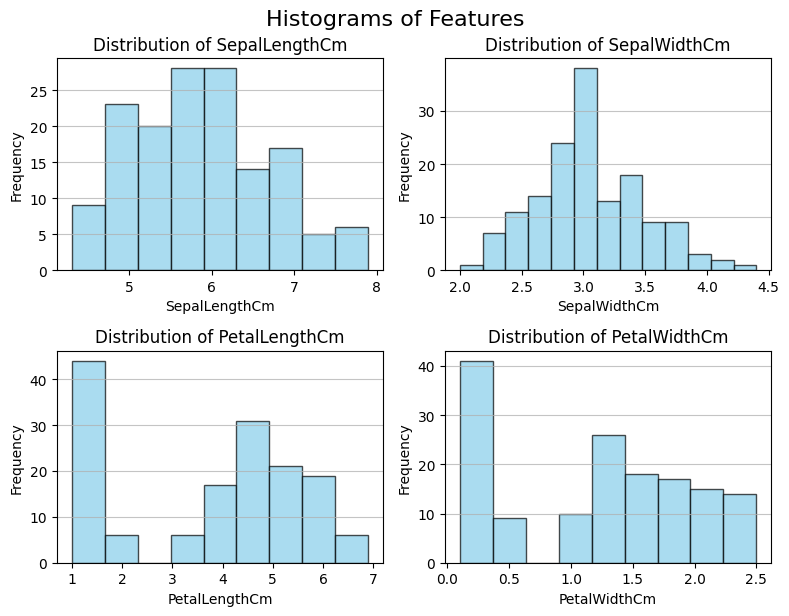

In [ ]:
df = df.drop(columns=['Id'])

numerical_features = df.select_dtypes(include=np.number).columns.tolist()

n_features = len(numerical_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(df[feature], bins='auto', color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Histograms of Features', y=1.02, fontsize=16)
plt.show()

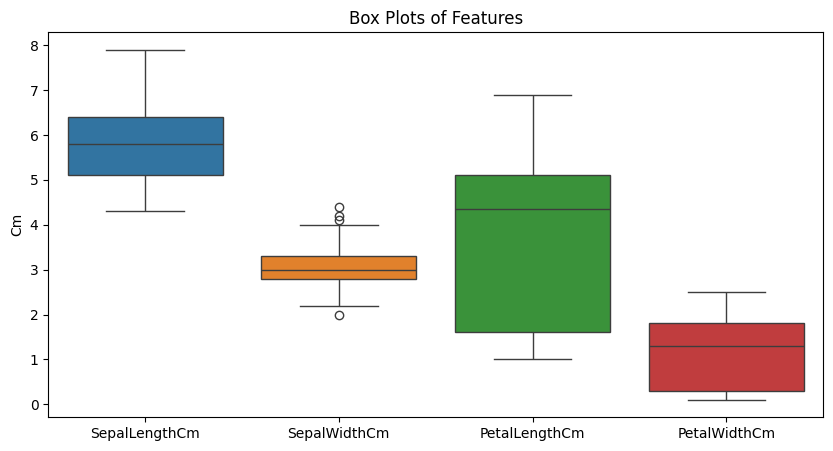

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.drop(columns='Species'))
plt.title('Box Plots of Features')
plt.ylabel('Cm')
plt.show()


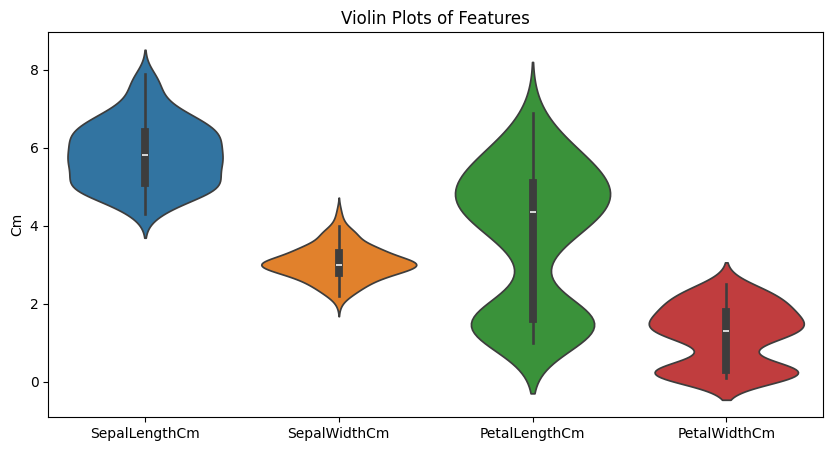

In [ ]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df.drop(columns='Species'))
plt.title('Violin Plots of Features')
plt.ylabel('Cm')
plt.show()

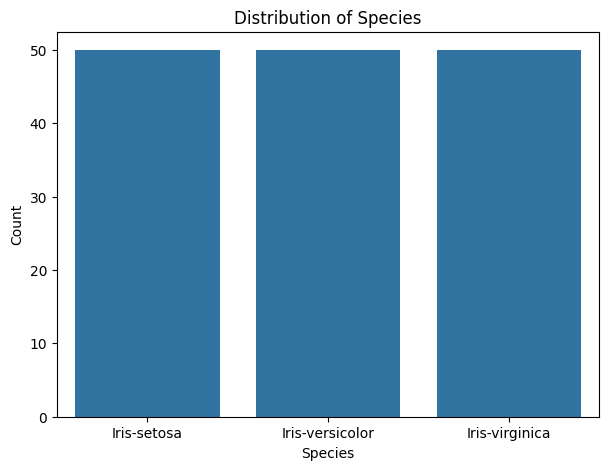

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Species')
plt.title('Distribution of Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

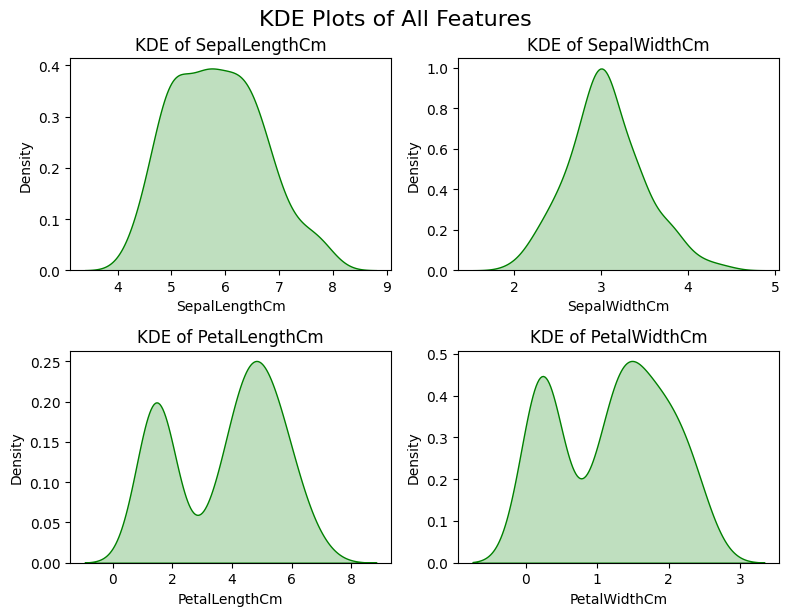

In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
n_cols = 2
n_rows = (len(numerical_features) + n_cols - 1) // n_cols
plt.figure(figsize=(n_cols * 4, n_rows * 3))
for i, feature in enumerate(numerical_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(data=df, x=feature, fill=True, color='green')
    plt.title(f'KDE of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.suptitle('KDE Plots of All Features', y=1.02, fontsize=16)
plt.show()

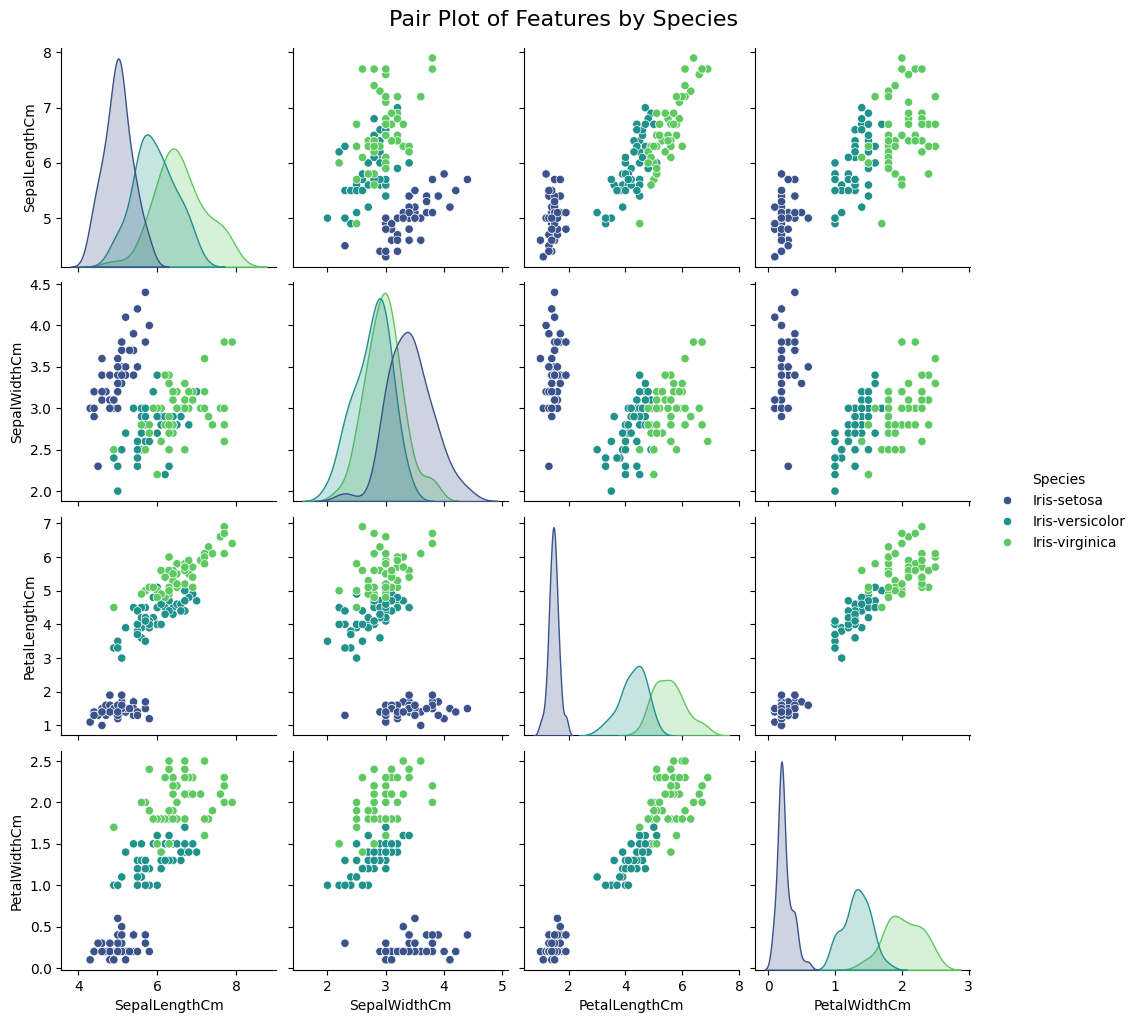

In [ ]:
sns.pairplot(df, hue='Species', diag_kind='kde', palette='viridis')
plt.suptitle('Pair Plot of Features by Species', y=1.02, fontsize=16)
plt.show()

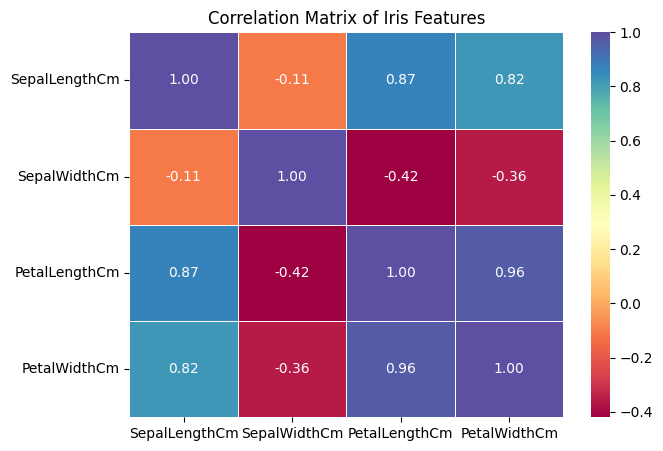

In [ ]:
plt.figure(figsize=(7, 5))
correlation_matrix = df.drop(columns='Species').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Spectral', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Iris Features')
plt.show()

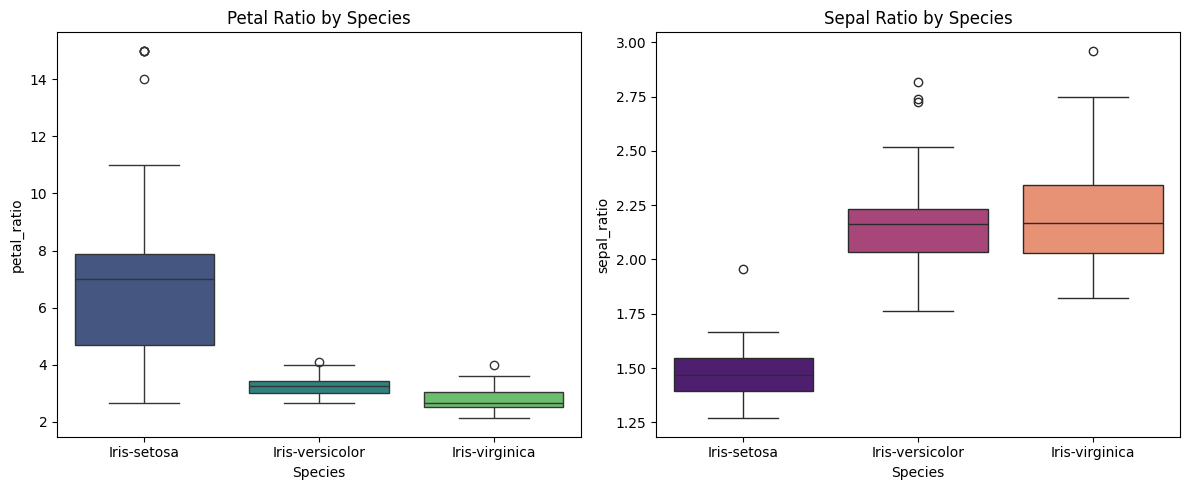

In [ ]:
df_eda = df.copy()
df_eda['petal_ratio'] = df_eda['PetalLengthCm'] / df_eda['PetalWidthCm']
df_eda['sepal_ratio'] = df_eda['SepalLengthCm'] / df_eda['SepalWidthCm']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_eda, x='Species', y='petal_ratio',hue='Species', palette='viridis')
plt.title('Petal Ratio by Species')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_eda, x='Species', y='sepal_ratio',hue='Species', palette='magma')
plt.title('Sepal Ratio by Species')
plt.tight_layout()
plt.show()

#Model Building

In [ ]:
X = df
test_data = df.drop(['Species'], axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features identified: {numerical_features}")
print(f"Categorical features identified: {categorical_features}")

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

Numerical features identified: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Categorical features identified: ['Species']


In [ ]:
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42)

}

In [ ]:
results = {}
for name, clf in classifiers.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    Precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    Recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {"Accuracy": accuracy, "Precision": Precision, "Recall": Recall}

results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)



Model Performance Comparison:
                        Accuracy  Precision  Recall
Random Forest                1.0        1.0     1.0
K-Nearest Neighbors          1.0        1.0     1.0
Support Vector Machine       1.0        1.0     1.0
